# РК2 по ТМО
### Бирюкова ЕИ 
### Группа ИУ5-61Б вариант 3

# Тема: Методы построения моделей машинного обучения.

#### Задача
Для заданного набора данных (вариант №3 - Набор данных по жилью в Бостоне) постройте модели классификации или регрессии (в зависимости от конкретной задачи, рассматриваемой в наборе данных). Для построения моделей используйте методы 1 и 2 (метод 1 - Линейная/логистическая регрессия; метод 2 - Случайный лес). Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.

*Примечание:*
- При решении задач можно выбирать любое подмножество признаков из приведенного набора данных.
- Для сокращения времени построения моделей можно использовать фрагмент набора данных (например, первые 200-500 строк)

#### Методы по варианту для группы ИУ5-61Б
1. Метод 1 - линейная/логистическая регрессия
2. Метод 2 - случайный лес

#### Набор данных №3 - Набор данных по жилью в Бостоне
https://www.kaggle.com/datasets/altavish/boston-housing-dataset

# Ход выполнения

Описание полей датасета - набор данных по жилью в Бостоне.

- CRIME - Уровень преступности на душу населения в разбивке по городам
- ZN - Доля жилых земель, разделенных на участки площадью более 25 000 кв.футов
- INDUS - Доля акров, не связанных с розничной торговлей, в штате ИНД в расчете на город
- CHAS - Фиктивная переменная (= 1, если участок граничит с рекой; 0 в противном случае)
- NOX - Концентрация оксидов азота NOX (частей на 10 миллионов)
- RM - Среднее количество комнат в жилом помещении по стране
- AGE - Доля квартир, занимаемых владельцами, построенных до 1940 года
- DIS - Взвешенные расстояния до пяти бостонских центров занятости
- RAD - Индекс доступности радиальных автомагистралей
- TAX - Ставка налога на недвижимость в размере 10 000 долларов США
- PTRATIO - Соотношение количества учеников и учителей по городам
- B = 1000(Bk - 0.63)^2, где Bk - доля чернокожих в населении в разбивке по городам
- LSTAT - Процент более низкого статуса населения
- MEDV - Стоимость домов, занимаемых владельцами, в среднем на 1000 долларов

Импортируем библиотеки для работы с датасетом.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

Прочитаем датасет и выведем первые пять строк.

In [15]:
df = pd.read_csv('HousingData.csv')
print("Первые 5 строк датасета:")
display(df.head())

Первые 5 строк датасета:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


Проверим наличие пропущенных значений в датасете.

In [16]:
print("\nПропущенные значения в датасете:")
print(df.isnull().sum())


Пропущенные значения в датасете:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


Заполним пропущенные значения в датасете медианными значениями.

In [17]:
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [18]:
print("\nПропущенные значения в датасете:")
print(df_imputed.isnull().sum())


Пропущенные значения в датасете:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


Подготовим данные и разделим их на тренировочный и тестовый наборы.

In [19]:
# Разделение на признаки и целевую переменную
X = df_imputed.drop('MEDV', axis=1)
y = df_imputed['MEDV']

# Разделение на тренировочный и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Построение модели с помощью метода №1 - Линейная регрессия

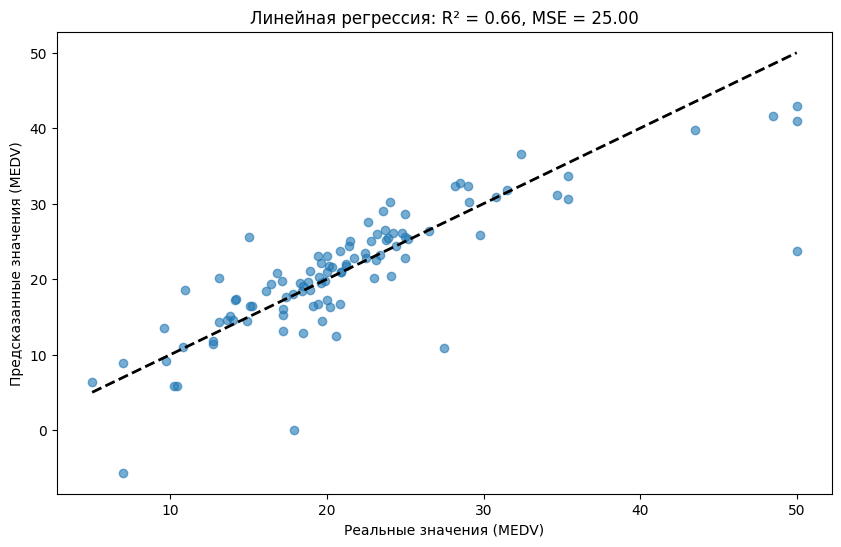

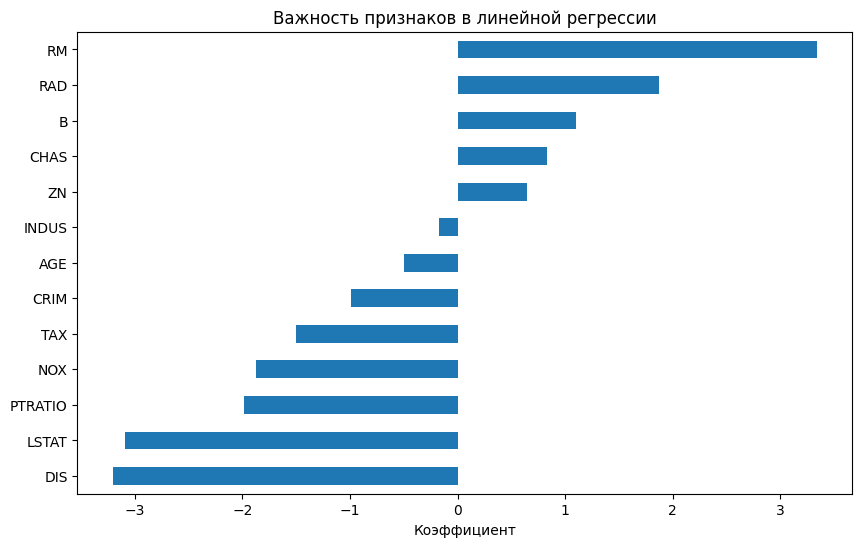

In [20]:
# Обучение модели
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Предсказания
y_pred_lr = lr.predict(X_test_scaled)

# Оценка качества
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Реальные значения (MEDV)')
plt.ylabel('Предсказанные значения (MEDV)')
plt.title(f'Линейная регрессия: R² = {r2_lr:.2f}, MSE = {mse_lr:.2f}')
plt.show()

# Важность признаков
lr_coef = pd.Series(lr.coef_, index=X.columns).sort_values()
plt.figure(figsize=(10, 6))
lr_coef.plot.barh()
plt.title('Важность признаков в линейной регрессии')
plt.xlabel('Коэффициент')
plt.show()

#### Построение модели с помощью метода №2 - Случайный лес

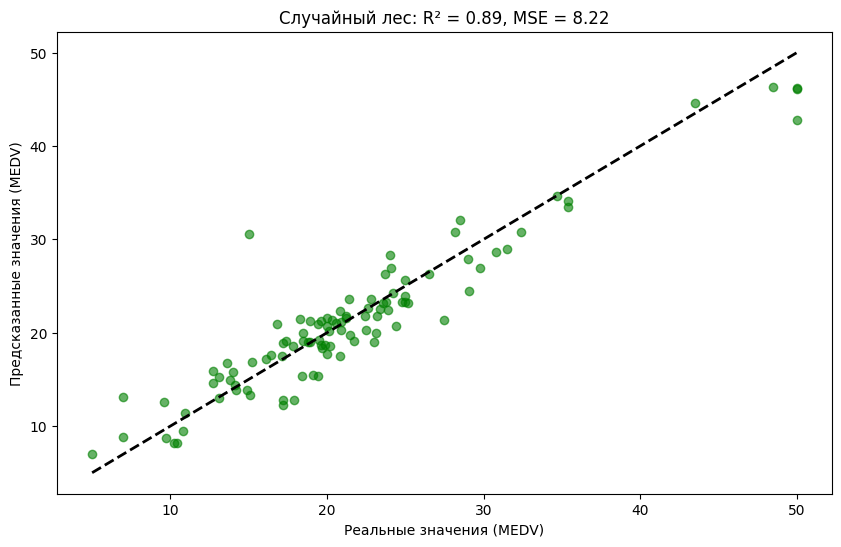

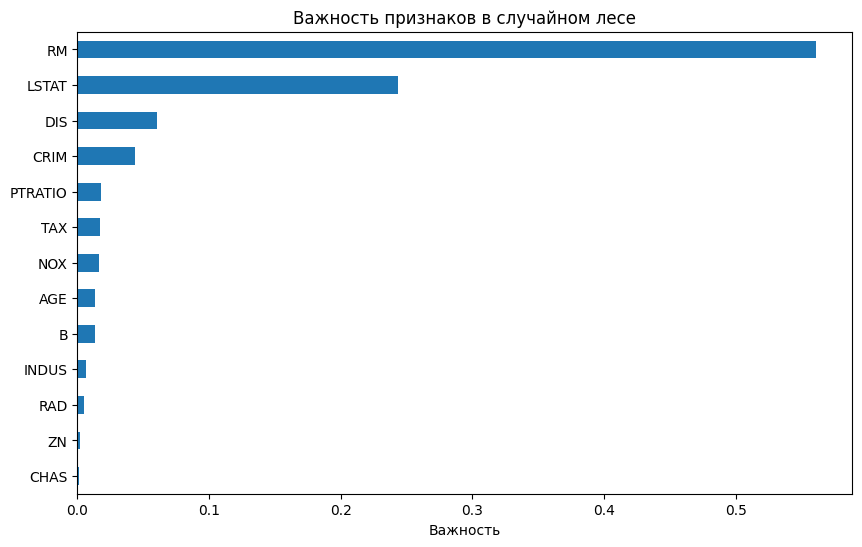

In [21]:
# Обучение модели
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Для RandomForest масштабирование не требуется

# Предсказания
y_pred_rf = rf.predict(X_test)

# Оценка качества
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Реальные значения (MEDV)')
plt.ylabel('Предсказанные значения (MEDV)')
plt.title(f'Случайный лес: R² = {r2_rf:.2f}, MSE = {mse_rf:.2f}')
plt.show()

# Важность признаков
rf_feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(10, 6))
rf_feature_importance.plot.barh()
plt.title('Важность признаков в случайном лесе')
plt.xlabel('Важность')
plt.show()

#### Сравнение моделей

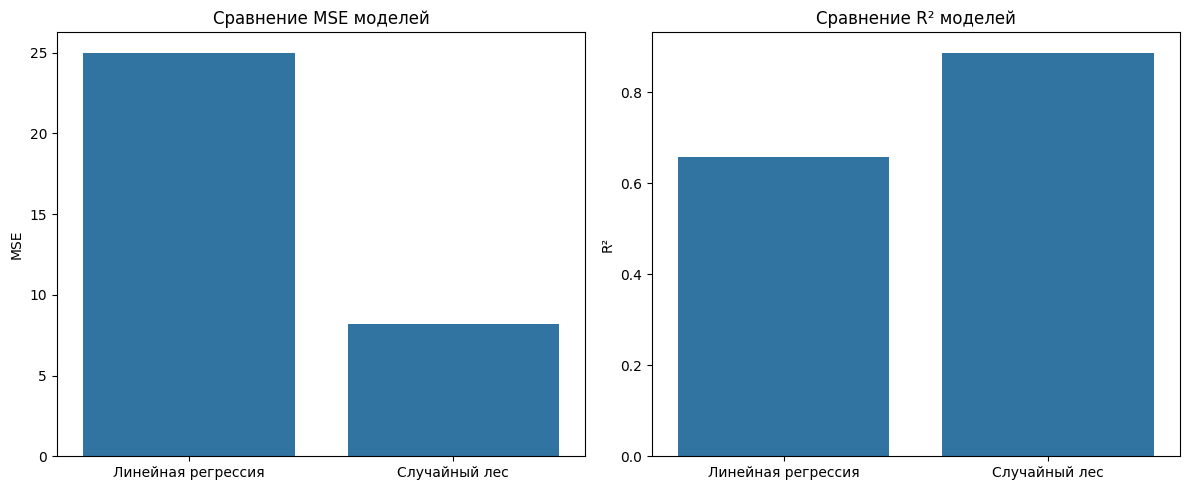

In [23]:
# Сравнение метрик
models = ['Линейная регрессия', 'Случайный лес']
mse_scores = [mse_lr, mse_rf]
r2_scores = [r2_lr, r2_rf]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=models, y=mse_scores)
plt.title('Сравнение MSE моделей')
plt.ylabel('MSE')

plt.subplot(1, 2, 2)
sns.barplot(x=models, y=r2_scores)
plt.title('Сравнение R² моделей')
plt.ylabel('R²')

plt.tight_layout()
plt.show()

#### Выводы

Ответим на начальные вопросы
1. Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). 
2. Какие метрики качества Вы использовали и почему? 
3. Какие выводы Вы можете сделать о качестве построенных моделей?

**Вопрос 1. - Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик).**

Получили следующие значения:
1. Линейная регрессия: R² = 0,66, MSE = 25

Модель объясняет 66% вариации цены жилья, что можно считать удовлетворительным, но не выдающимся результатом. Значение среднего квадрата ошибки довольно высокое.

2. Случайный лес: R² = 0,89, MSE = 8,22

Модель объясняет 89% вариации цены жилья, что можно считать довольно хорошим результатом. Значение среднего квадрата ошибки понизилось в сравнении с тем же показателем при использовании линейной регрессии (в 3 раза).

---

**Вопрос 2 - Какие метрики качества Вы использовали и почему?.**

Для оценки моделей использовалось две ключевые метрики:
1. Коэффициент детерминации (R²)
    - Показывает долю дисперсии зависимой переменной, которая объясняется моделью
    - Диапазон значений: от 0 до 1 (чем ближе к 1, тем лучше)
    - Интерпретируемость: R²=0.66 означает, что модель объясняет 66% вариации данных
2. Среднеквадратичная ошибка (MSE)
    - Показывает средний квадрат разницы между предсказанными и реальными значениями
    - Чем меньше значение, тем лучше
    - Сохраняет единицы измерения в квадрате, что полезно для понимания масштаба ошибки

Эти метрики выбраны потому что:
- Они дополняют друг друга: R² показывает относительное качество, а MSE - абсолютное
- Широко используются в задачах регрессии
- Позволяют сравнить модели между собой
- Имеют четкую интерпретацию

---

**Вопрос 3 - Какие выводы Вы можете сделать о качестве построенных моделей?**

1. Качество моделей:
    - Случайный лес значительно превосходит линейную регрессию по обеим метрикам
    - Разница в R² (0.89 vs 0.66) существенна и статистически значима
    - Улучшение MSE с 25 до 8.22 означает практическую значимость выбора случайного леса
2. Интерпретируемость vs точность:
    - Линейная регрессия проще интерпретируется (можно анализировать коэффициенты)
    - Случайный лес дает более точные прогнозы, но сложнее для интерпретации
3. Выводы:
    - Для аналитических задач, где важна интерпретация, можно использовать линейную регрессию, понимая ее ограничения
    - Для прогнозирования и получения максимально точных результатов следует выбрать случайный лес
    - Для дальнейшего улучшения линейной регрессии можно попробовать:
        - Добавление полиномиальных признаков
        - Учет взаимодействий между переменными
        - Преобразование целевой переменной